###### import libraries and load dataset 


In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

sns.set_style('whitegrid')
plt.style.use('fivethirtyeight')

In [3]:
deliveries =  pd.read_csv('deliveries.csv')
matches = pd.read_csv('matches.csv')

In [4]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [5]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [6]:
matches.shape

(1095, 20)

In [7]:
deliveries.shape

(260920, 17)

In [8]:
matches['team1'].value_counts()

team1
Royal Challengers Bangalore    135
Chennai Super Kings            128
Mumbai Indians                 123
Kolkata Knight Riders          121
Rajasthan Royals               101
Kings XI Punjab                 92
Sunrisers Hyderabad             86
Delhi Daredevils                85
Delhi Capitals                  41
Deccan Chargers                 39
Punjab Kings                    31
Lucknow Super Giants            23
Pune Warriors                   23
Gujarat Titans                  21
Gujarat Lions                   16
Royal Challengers Bengaluru      9
Kochi Tuskers Kerala             7
Rising Pune Supergiant           7
Rising Pune Supergiants          7
Name: count, dtype: int64

In [9]:
matches['team2'].value_counts()

team2
Mumbai Indians                 138
Kolkata Knight Riders          130
Rajasthan Royals               120
Chennai Super Kings            110
Royal Challengers Bangalore    105
Kings XI Punjab                 98
Sunrisers Hyderabad             96
Delhi Daredevils                76
Delhi Capitals                  50
Deccan Chargers                 36
Punjab Kings                    25
Gujarat Titans                  24
Pune Warriors                   23
Lucknow Super Giants            21
Gujarat Lions                   14
Rising Pune Supergiant           9
Kochi Tuskers Kerala             7
Rising Pune Supergiants          7
Royal Challengers Bengaluru      6
Name: count, dtype: int64

In [10]:
deliveries['batting_team'].value_counts()

batting_team
Mumbai Indians                 31437
Kolkata Knight Riders          29514
Chennai Super Kings            28651
Royal Challengers Bangalore    28205
Rajasthan Royals               26242
Kings XI Punjab                22646
Sunrisers Hyderabad            21843
Delhi Daredevils               18786
Delhi Capitals                 10946
Deccan Chargers                 9034
Punjab Kings                    6833
Gujarat Titans                  5494
Pune Warriors                   5443
Lucknow Super Giants            5400
Gujarat Lions                   3566
Rising Pune Supergiant          1900
Royal Challengers Bengaluru     1818
Kochi Tuskers Kerala            1582
Rising Pune Supergiants         1580
Name: count, dtype: int64

###### Data Cleaning

In [11]:
matches.replace({
    'Rising Pune Supergiants': 'Rising Pune Supergiant'
},inplace=True
                
               )

In [12]:
matches['team1'].value_counts()

team1
Royal Challengers Bangalore    135
Chennai Super Kings            128
Mumbai Indians                 123
Kolkata Knight Riders          121
Rajasthan Royals               101
Kings XI Punjab                 92
Sunrisers Hyderabad             86
Delhi Daredevils                85
Delhi Capitals                  41
Deccan Chargers                 39
Punjab Kings                    31
Pune Warriors                   23
Lucknow Super Giants            23
Gujarat Titans                  21
Gujarat Lions                   16
Rising Pune Supergiant          14
Royal Challengers Bengaluru      9
Kochi Tuskers Kerala             7
Name: count, dtype: int64

In [13]:
matches.replace({
    'Delhi Daredevils':'Delhi Capitals',
    'Royal Challengers Bengaluru ': 'Royal Challengers Bengaluru',
    'Punjab Kings ': 'Punjab Kings'
},inplace=True)


In [14]:
matches['team1'].value_counts()


team1
Royal Challengers Bangalore    135
Chennai Super Kings            128
Delhi Capitals                 126
Mumbai Indians                 123
Kolkata Knight Riders          121
Rajasthan Royals               101
Kings XI Punjab                 92
Sunrisers Hyderabad             86
Deccan Chargers                 39
Punjab Kings                    31
Lucknow Super Giants            23
Pune Warriors                   23
Gujarat Titans                  21
Gujarat Lions                   16
Rising Pune Supergiant          14
Royal Challengers Bengaluru      9
Kochi Tuskers Kerala             7
Name: count, dtype: int64

In [15]:
matches[matches['team1'].str.contains('Kings', na=False)]['team1'].unique()

array(['Kings XI Punjab', 'Chennai Super Kings', 'Punjab Kings'],
      dtype=object)

In [16]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [17]:
deliveries['batting_team'].replace({'Rising Pune Supergiants': 'Rising Pune Supergiant'}, inplace=True)
deliveries['bowling_team'].replace({'Rising Pune Supergiants':'Rising Pune Supergiant'}, inplace=True)

C:\Users\Himansu saxsena\AppData\Local\Temp\ipykernel_13952\2985160984.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  deliveries['batting_team'].replace({'Rising Pune Supergiants': 'Rising Pune Supergiant'}, inplace=True)
C:\Users\Himansu saxsena\AppData\Local\Temp\ipykernel_13952\2985160984.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermedia

In [18]:
deliveries.replace({
    'Delhi Daredevils':'Delhi Capitals',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Kings XI Punjab': 'Punjab Kings'
},inplace=True)


In [19]:
deliveries[deliveries['batting_team'].str.contains('Royal', na=False)]['batting_team'].unique()

array(['Royal Challengers Bengaluru', 'Rajasthan Royals'], dtype=object)

In [20]:
deliveries['batting_team'].value_counts()

batting_team
Mumbai Indians                 31437
Royal Challengers Bengaluru    30023
Delhi Capitals                 29732
Kolkata Knight Riders          29514
Punjab Kings                   29479
Chennai Super Kings            28651
Rajasthan Royals               26242
Sunrisers Hyderabad            21843
Deccan Chargers                 9034
Gujarat Titans                  5494
Pune Warriors                   5443
Lucknow Super Giants            5400
Gujarat Lions                   3566
Rising Pune Supergiant          3480
Kochi Tuskers Kerala            1582
Name: count, dtype: int64

In [21]:
deliveries['bowling_team'].value_counts()


bowling_team
Mumbai Indians                 31505
Royal Challengers Bengaluru    30159
Delhi Capitals                 29941
Kolkata Knight Riders          29663
Punjab Kings                   29202
Chennai Super Kings            28576
Rajasthan Royals               26432
Sunrisers Hyderabad            21717
Deccan Chargers                 9039
Pune Warriors                   5457
Gujarat Titans                  5301
Lucknow Super Giants            5226
Gujarat Lions                   3545
Rising Pune Supergiant          3543
Kochi Tuskers Kerala            1614
Name: count, dtype: int64

In [22]:
matches['city'].isna().sum()

np.int64(51)

In [23]:
matches['method'].value_counts()

method
D/L    21
Name: count, dtype: int64

In [24]:
matches['city'].fillna('Unknown',inplace=True)
matches['method'].fillna('Non D/L', inplace =  True)

C:\Users\Himansu saxsena\AppData\Local\Temp\ipykernel_13952\3206085229.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  matches['city'].fillna('Unknown',inplace=True)
C:\Users\Himansu saxsena\AppData\Local\Temp\ipykernel_13952\3206085229.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves a

In [25]:
matches['city'].isna().sum()

np.int64(0)

In [26]:
matches['method'].value_counts()

method
Non D/L    1074
D/L          21
Name: count, dtype: int64

###### Success Rate of Teams

In [27]:
def random_colors(no_of_colors):
    return['#' + ''.join([np.random.choice(list('0123456789ABCDEF'))for _ in range (6) ]) for _ in range (no_of_colors)]
    

In [28]:
random_colors(6)

['#A90B12', '#7C0469', '#E51792', '#648C06', '#F1B87A', '#C76257']

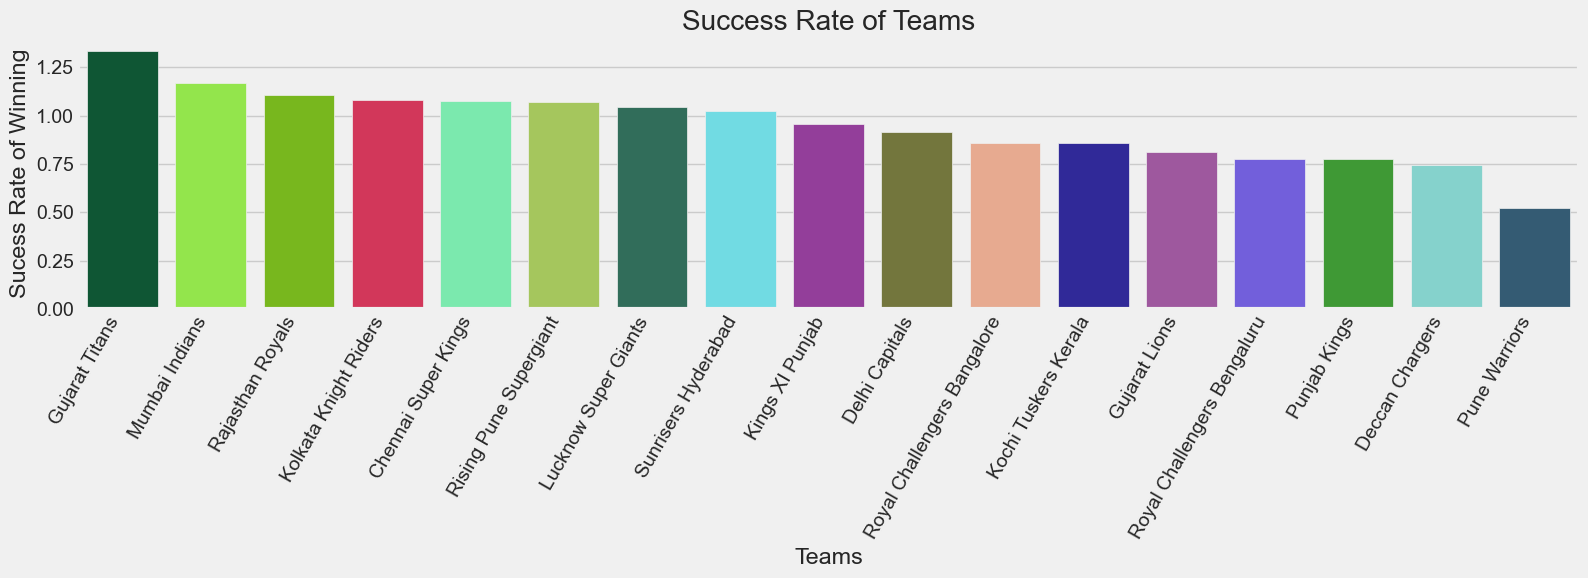

In [29]:
success_ratio = matches.groupby('winner').count()['id']/matches.groupby('team1').count()['id']
success_ratio_desc = success_ratio.sort_values(ascending=False)

plt.figure(figsize=(16,6))
sns.barplot(x =  success_ratio_desc.index, y = success_ratio_desc.values, hue  = success_ratio_desc.index, palette = random_colors(len(success_ratio_desc)))
plt.title('Success Rate of Teams')
plt.xlabel('Teams')
plt.ylabel('Sucess Rate of Winning')
plt.xticks(rotation = 60, ha ='right')
plt.tight_layout()
plt.show()

###### most titles wins

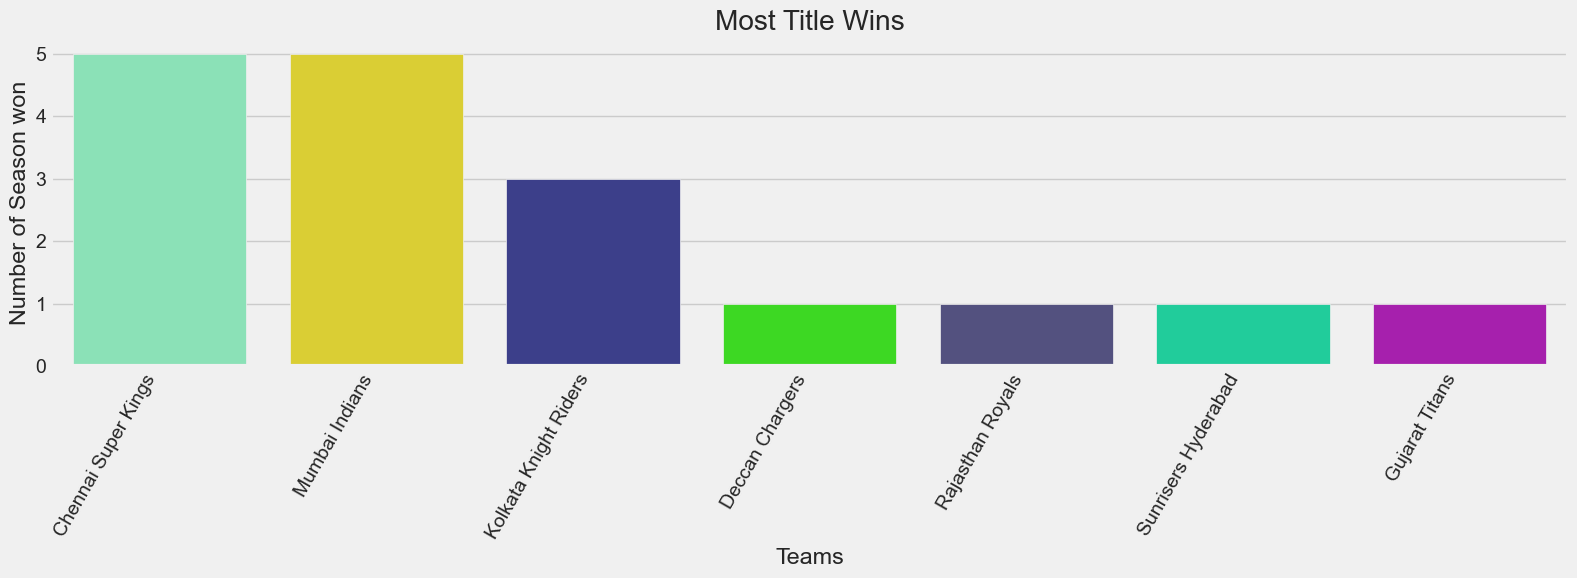

In [30]:
winner_counts = matches.groupby('season')[['season','winner']].tail(1)['winner'].value_counts()

plt.figure(figsize=(16,6))
sns.barplot(x =  winner_counts.index, y = winner_counts.values, hue  = winner_counts.index, palette = random_colors(len(winner_counts)))
plt.title('Most Title Wins')
plt.xlabel('Teams')
plt.ylabel('Number of Season won')
plt.xticks(rotation = 60, ha ='right')
plt.tight_layout()
plt.show()

###### Top 10  Players with Most

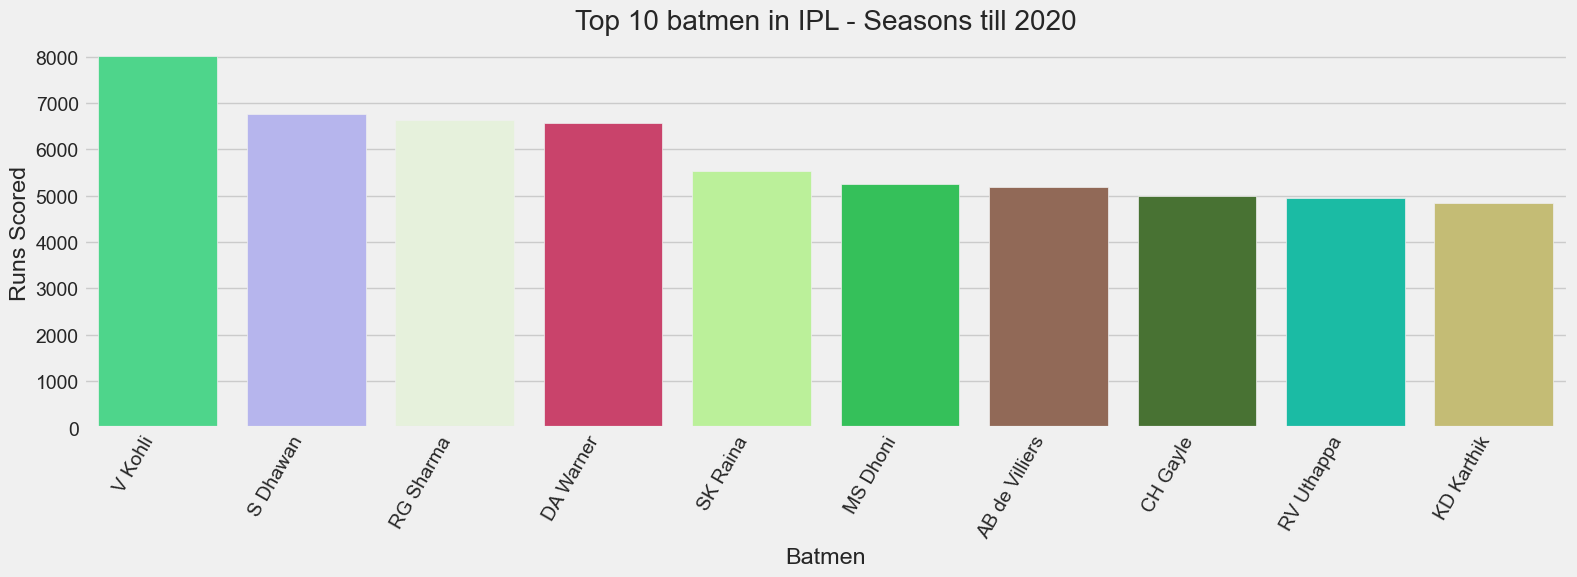

In [31]:
batting_tot = deliveries.groupby('batter')['batsman_runs'].sum().reset_index(name = 'Runs')
top_batsmen = batting_tot.sort_values(by = 'Runs', ascending = False)[:10]
plt.figure(figsize=(16,6))
sns.barplot(x='batter',y='Runs',data = top_batsmen,hue  = 'batter',palette = random_colors(10))
plt.title('Top 10 batmen in IPL - Seasons till 2020')
plt.xlabel('Batmen')
plt.ylabel('Runs Scored')
plt.xticks(rotation = 60, ha ='right')
plt.tight_layout()
plt.show()


###### Top 10 Best Performance in a match

In [32]:
deliveries.head(1)

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN


In [33]:
batting_ings =  deliveries.groupby(['match_id','batter'])['batsman_runs'].sum().reset_index(name='Innings Runs')
top_batsmen_scores = batting_ings.sort_values(by =  'Innings Runs',ascending = False)[:10]

In [34]:
batsman_ball_faced = deliveries.groupby(['match_id','batter'])['batsman_runs'].count().reset_index(name='Balls Faced')


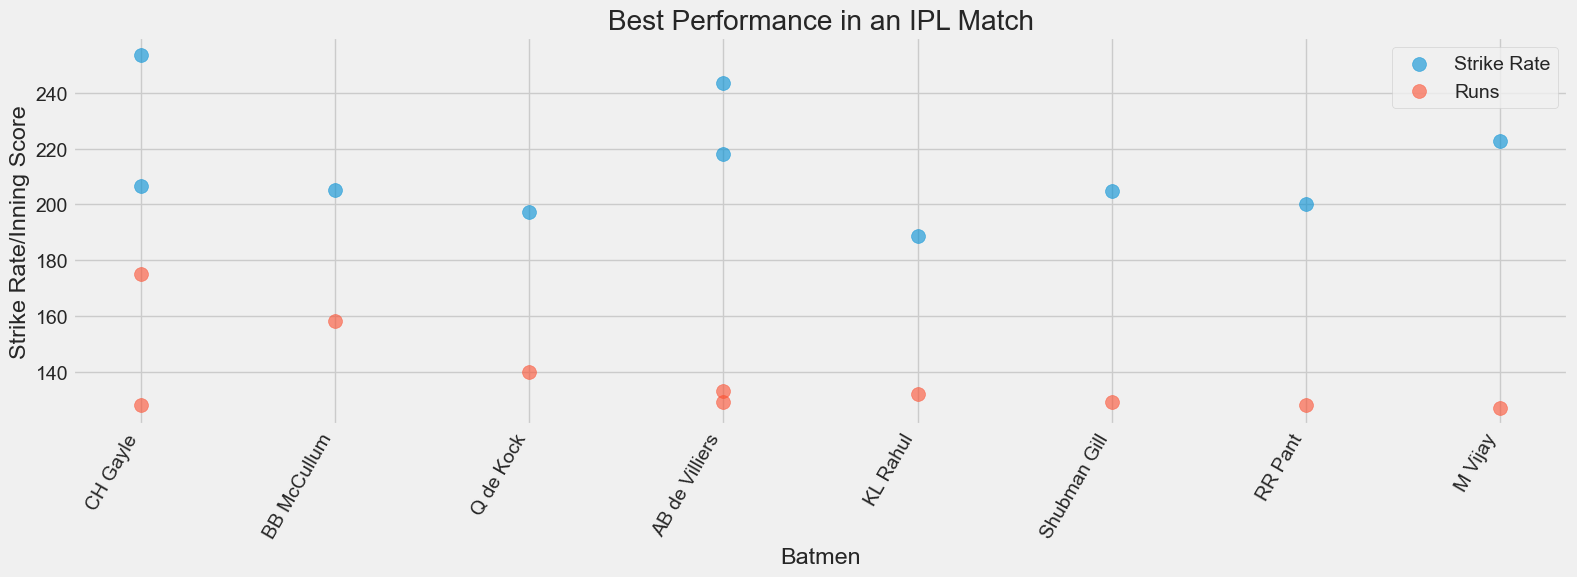

In [35]:
batsmen_performance = pd.merge(top_batsmen_scores,batsman_ball_faced, how = 'inner', on = ['match_id','batter'])
batsmen_performance['Strike Rate for Match' ] = np.round(batsmen_performance['Innings Runs']*100/batsmen_performance['Balls Faced'],2)
batsmen_performance
plt.figure(figsize=(16,6))
plt.scatter(batsmen_performance['batter'], batsmen_performance['Strike Rate for Match'], label = 'Strike Rate', s =  100, alpha = 0.6)
plt.scatter(batsmen_performance['batter'], batsmen_performance['Innings Runs'], label = 'Runs', s =  100, alpha = 0.6)
plt.title('Best Performance in an IPL Match')
plt.xlabel('Batmen')
plt.ylabel('Strike Rate/Inning Score')
plt.legend()
plt.xticks(rotation = 60, ha ='right')
plt.tight_layout()
plt.show()


###### Top 10 bowling till 2020

In [64]:
bowling_wickets.groupby('bowler')['dismissal_kind'].count().reset_index(name =  'Wickets').sort_values(by= 'Wickets', ascending = False)[:10]

,bowler,Wickets
524,YS Chahal,205
348,PP Chawla,192
119,DJ Bravo,183
355,R Ashwin,181
71,B Kumar,181
446,SP Narine,180
8,A Mishra,174
438,SL Malinga,170
193,JJ Bumrah,168
373,RA Jadeja,160


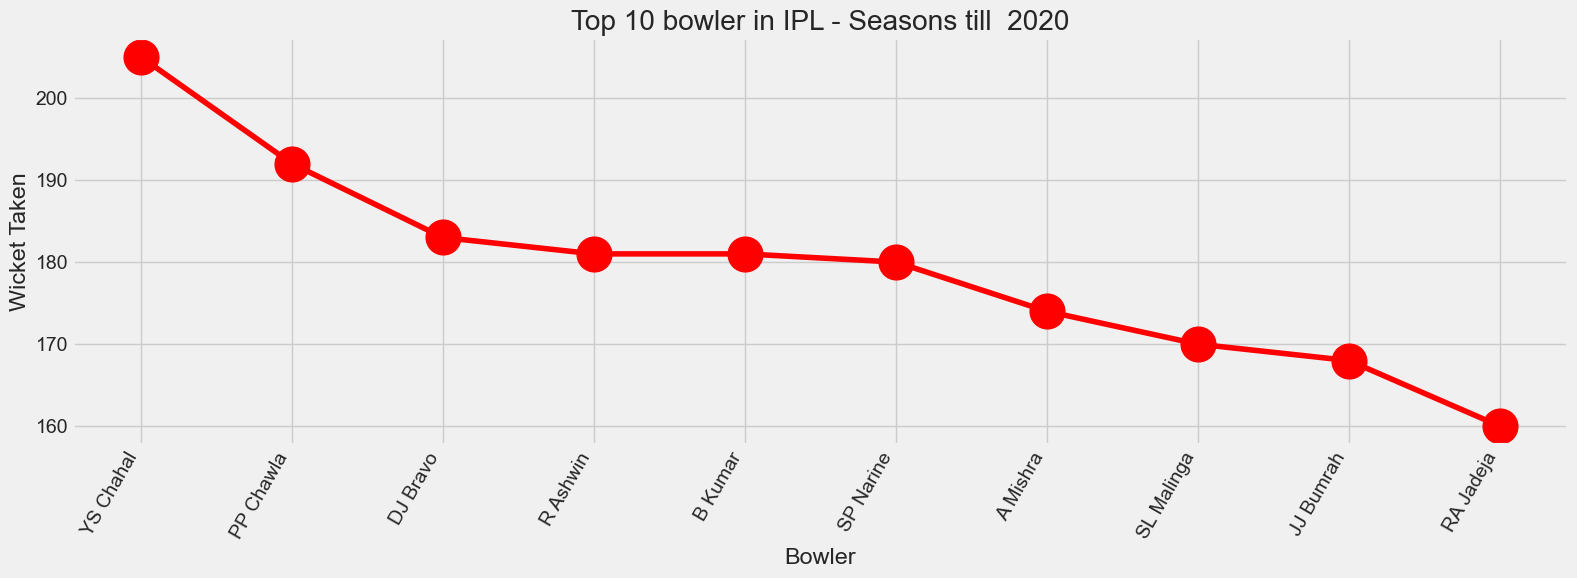

In [65]:
bowling_wickets =  deliveries[deliveries['dismissal_kind'] != 'run out']
top_bowlers =  bowling_wickets.groupby('bowler')['dismissal_kind'].count().reset_index(name =  'Wickets').sort_values(by= 'Wickets', ascending = False)[:10]
plt.figure(figsize=(16,6))
plt.plot(top_bowlers['bowler'],top_bowlers['Wickets'], marker='o', color = 'red', ms = 25)
plt.title('Top 10 bowler in IPL - Seasons till  2020')
plt.xlabel('Bowler')
plt.ylabel('Wicket Taken')
plt.xticks(rotation = 60, ha ='right')
plt.tight_layout()
plt.show()


###### Top bowling performance 

In [66]:
match_bowling_top = bowling_wickets.groupby(['match_id','bowler'])['dismissal_kind'].count().reset_index(name =  'Wickets').sort_values(by= 'Wickets', ascending = False)[:10]
match_bowling_top



,match_id,bowler,Wickets
8498,1178394,AS Joseph,6
290,336005,Sohail Tanvir,6
6608,980979,A Zampa,6
10716,1304076,YS Chahal,5
12570,1426276,Sandeep Sharma,5
3066,548311,RA Jadeja,5
11253,1359477,MA Wood,5
9667,1254058,HV Patel,5
3208,548323,SP Narine,5
2167,501201,SL Malinga,5


In [67]:
match_bowler_runs = deliveries.groupby(['match_id', 'bowler'])['total_runs'].sum().reset_index(name = 'Runs Conceded')
match_bowler_runs

,match_id,bowler,Runs Conceded
0,335982,AA Noffke,41
1,335982,AB Agarkar,25
2,335982,AB Dinda,9
3,335982,CL White,24
4,335982,I Sharma,13
...,...,...,...
12973,1426312,PJ Cummins,18
12974,1426312,SP Narine,20
12975,1426312,Shahbaz Ahmed,28
12976,1426312,T Natarajan,29


In [68]:
match_bowler_performance = pd.merge(match_bowler_runs, match_bowling_top, how= 'inner', on = ['match_id', 'bowler'])
match_bowler_performance

,match_id,bowler,Runs Conceded,Wickets
0,336005,Sohail Tanvir,15,6
1,501201,SL Malinga,13,5
2,548311,RA Jadeja,16,5
3,548323,SP Narine,20,5
4,980979,A Zampa,19,6
5,1178394,AS Joseph,14,6
6,1254058,HV Patel,27,5
7,1304076,YS Chahal,40,5
8,1359477,MA Wood,14,5
9,1426276,Sandeep Sharma,18,5


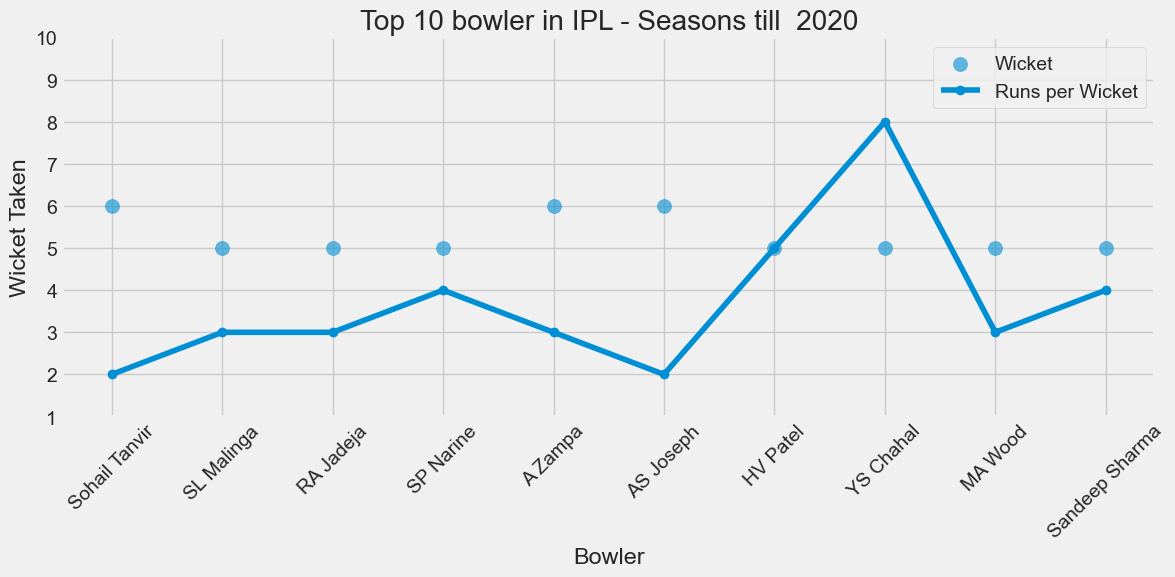

In [69]:
match_bowler_performance['Runs per Wicket'] =  np.round(match_bowler_performance['Runs Conceded']/match_bowler_performance['Wickets'] ,0)

plt.figure(figsize=(12,6))
plt.scatter(match_bowler_performance['bowler'],match_bowler_performance['Wickets'], label='Wicket', s = 100, alpha = 0.6)
plt.plot(match_bowler_performance['bowler'],match_bowler_performance['Runs per Wicket'], marker = 'o',label = 'Runs per Wicket')
plt.title('Top 10 bowler in IPL - Seasons till  2020')
plt.xlabel('Bowler')
plt.ylabel('Wicket Taken')
plt.legend()
plt.xticks(rotation =45)
plt.yticks(range(1, 11))
plt.tight_layout()
plt.show()

######  Top 10 cities by numbe of matches 

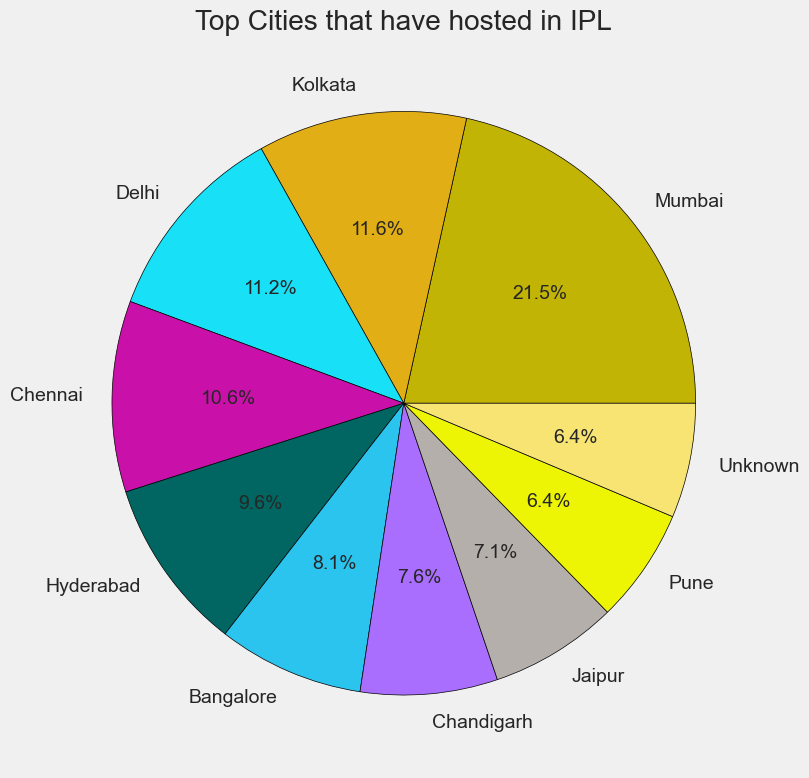

In [70]:
top_cities  =  matches['city'].value_counts().reset_index(name='Match Count')[:10]
plt.figure(figsize =  (8,8))
plt.pie(top_cities['Match Count'], labels  = top_cities['city'],colors = random_colors(10),autopct = '%1.1f%%', wedgeprops =dict(edgecolor = 'black'))
plt.title('Top Cities that have hosted in IPL')
plt.tight_layout()
plt.show()